# ACTIVIDAD 16 
VICTOR CEN

In [3]:
pip install deap

Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.3 MB/s  0:00:04 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

In [4]:
def funcion_objetivo(ind):
    if any(g > 100 or g < -100 for g in ind):
        return (-1,)
    return (math.sqrt(ind[0]**2 + ind[1]**2),)

def crear_toolbox(n_poblacion):
    tb = base.Toolbox()
    tb.register("attr_uniform", random.uniform, -100, 100)
    tb.register("individual", tools.initRepeat, creator.Individual, tb.attr_uniform, 2)
    tb.register("population", tools.initRepeat, list, tb.individual, n_poblacion)
    tb.register("evaluate", funcion_objetivo)
    tb.register("mate", tools.cxOnePoint)
    tb.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
    tb.register("select", tools.selTournament, tournsize=3)
    return tb

In [6]:
def correr_ga(n_poblacion, ngen=20, seed=42):
    random.seed(seed)
    tb = crear_toolbox(n_poblacion)

    pop = tb.population()
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    pop, log = algorithms.eaSimple(
        pop,
        tb,
        cxpb=0.5,
        mutpb=0.2,
        ngen=ngen,
        stats=stats,
        halloffame=hof,
        verbose=False
    )

    return {
        "poblacion": n_poblacion,
        "mejor_fitness": hof[0].fitness.values[0],
        "mejor_individuo": list(hof[0]),
        "log": pd.DataFrame(log)
    }

In [8]:
res30 = correr_ga(30, ngen=20, seed=42)
res50 = correr_ga(50, ngen=20, seed=42)

print("Población = 30")
print("Mejor fitness:", round(res30["mejor_fitness"], 6))
print("Mejor individuo:", [round(x, 6) for x in res30["mejor_individuo"]])

print("\nPoblación = 50")
print("Mejor fitness:", round(res50["mejor_fitness"], 6))
print("Mejor individuo:", [round(x, 6) for x in res50["mejor_individuo"]])

Población = 30
Mejor fitness: 140.100794
Mejor individuo: [-99.346385, -98.785264]

Población = 50
Mejor fitness: 140.676643
Mejor individuo: [99.475194, -99.471622]


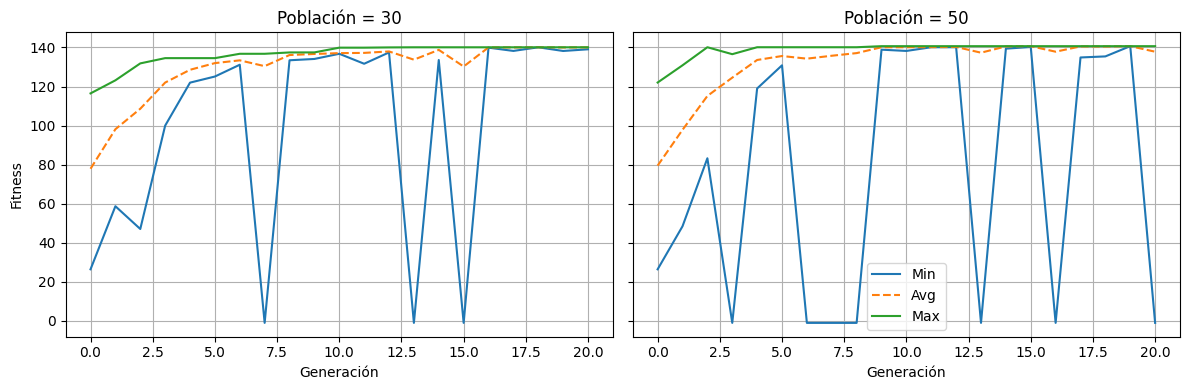

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for eje, res in zip(ax, [res30, res50]):
    log = res["log"]
    eje.plot(log["gen"], log["min"], label="Min")
    eje.plot(log["gen"], log["avg"], "--", label="Avg")
    eje.plot(log["gen"], log["max"], label="Max")
    eje.set_title(f'Población = {res["poblacion"]}')
    eje.set_xlabel("Generación")
    eje.grid(True)

ax[0].set_ylabel("Fitness")
ax[1].legend()
plt.tight_layout()
plt.show()

In [12]:
optimo_real = math.sqrt(100**2 + 100**2)

tabla = pd.DataFrame({
    "Población": [30, 50],
    "Generaciones": [20, 20],
    "Mejor fitness": [res30["mejor_fitness"], res50["mejor_fitness"]],
    "Mejor individuo": [res30["mejor_individuo"], res50["mejor_individuo"]]
})

tabla["Diferencia al óptimo"] = optimo_real - tabla["Mejor fitness"]
tabla.round(6)

,Población,Generaciones,Mejor fitness,Mejor individuo,Diferencia al óptimo
0,30,20,140.100794,"[-99.34638537370458, -98.78526358100852]",1.320562
1,50,20,140.676643,"[99.47519355610216, -99.47162247430336]",0.744714


In [14]:
mejor = res30 if res30["mejor_fitness"] > res50["mejor_fitness"] else res50

print(f"La población de {mejor['poblacion']} individuos obtuvo el mejor fitness "
      f"({mejor['mejor_fitness']:.6f}), por lo que presentó la mejor aproximación al óptimo teórico.")

La población de 50 individuos obtuvo el mejor fitness (140.676643), por lo que presentó la mejor aproximación al óptimo teórico.


Se implementó el algoritmo genético para poblaciones de 30 y 50 individuos, manteniendo 20 generaciones. En ambos casos se obtuvieron soluciones cercanas al óptimo teórico. Sin embargo, la población que obtuvo el mayor fitness presentó la mejor aproximación al valor máximo de la función, lo que indica un mejor desempeño en la búsqueda de la solución.